<h1 align="center">Projet 02: Analysez des données de systèmes éducatifs</h1>

##  Introduction 



### Contexte de la mission
Dans le cadre de ce projet, j’interviens en tant que **Data Scientist** au sein de la start-up **Academy**, spécialisée dans la production de contenus de formation en ligne destinés à un public de niveau lycée et universitaire.



### Enjeu stratégique
L’entreprise souhaite aujourd’hui engager une réflexion stratégique autour de son **expansion à l’international**. Pour cela, une première mission d’analyse exploratoire m’a été confiée par mon manager, Mark.



### Objectifs de l'analyse
L’objectif est d’examiner des données sur l’éducation issues de la **Banque Mondiale**, afin de :
* **Identifier des pays** présentant un fort potentiel de clients pour les services d'Academy.
* **Comprendre l'évolution** de ce potentiel dans le temps (tendances démographiques et éducatives).

##  EXERCICE_01 Une première analyse en surface des différents jeux de données. 

### Importation des librairies Python utiles dans notre projet d'analyse des données 

In [253]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pycountry
from sklearn.preprocessing import MinMaxScaler

### 1.1 Chargement des jeux de données sur Notebook

Nous commençons par charger les différents fichiers mis à disposition dans le projet.

In [ ]:
path_country =  "data/EdStatsCountry.csv"
path_series =   "data/EdStatsSeries.csv"
path_data =  "data/EdStatsData.csv"
path_country_series = "data/EdStatsCountry-Series.csv"
path_footnote =   "data/EdStatsFootNote.csv"

df_country = pd.read_csv(path_country)
df_series = pd.read_csv(path_series)
df_data = pd.read_csv(path_data)
df_country_series = pd.read_csv(path_country_series)
df_footnote = pd.read_csv(path_footnote)



### 1.2 Collection des premières informations sur chaque jeu de données

In [335]:

def analyse_df(df, nom):
    print(f"\n=== {nom} ===")
    
    # Taille
    print(f"Taille : {df.shape[0]} lignes, {df.shape[1]} colonnes")
    
    # Doublons
    print(f"Doublons : {df.duplicated().sum()}")
    
    # Valeurs manquantes
    nulls = df.isnull().sum()
    nb_null_cols = (nulls > 0).sum()
    print(f"Colonnes avec valeurs manquantes : {nb_null_cols}")



datasets = {
    "df_country": df_country,
    "df_series": df_series,
    "df_data": df_data,
    "df_country_series": df_country_series,
    "df_footnote": df_footnote
}

for nom, df in datasets.items():
    df.columns = df.columns.str.strip()
    
    display(df.head())
    analyse_df(df, nom)




,Country Code,Short Name,Table Name,Long Name,2-alpha code,Currency Unit,Special Notes,Region,Income Group,WB-2 code,...,IMF data dissemination standard,Latest population census,Latest household survey,Source of most recent Income and expenditure data,Vital registration complete,Latest agricultural census,Latest industrial data,Latest trade data,Latest water withdrawal data,Unnamed: 31
0,ABW,Aruba,Aruba,Aruba,AW,Aruban florin,SNA data for 2000-2011 are updated from offici...,Latin America & Caribbean,High income: nonOECD,AW,...,NaN,2010,NaN,NaN,Yes,NaN,NaN,2012.0,NaN,NaN
1,AFG,Afghanistan,Afghanistan,Islamic State of Afghanistan,AF,Afghan afghani,Fiscal year end: March 20; reporting period fo...,South Asia,Low income,AF,...,General Data Dissemination System (GDDS),1979,"Multiple Indicator Cluster Survey (MICS), 2010/11","Integrated household survey (IHS), 2008",NaN,2013/14,NaN,2012.0,2000,NaN
2,AGO,Angola,Angola,People's Republic of Angola,AO,Angolan kwanza,"April 2013 database update: Based on IMF data,...",Sub-Saharan Africa,Upper middle income,AO,...,General Data Dissemination System (GDDS),1970,"Malaria Indicator Survey (MIS), 2011","Integrated household survey (IHS), 2008",NaN,2015,NaN,NaN,2005,NaN
3,ALB,Albania,Albania,Republic of Albania,AL,Albanian lek,NaN,Europe & Central Asia,Upper middle income,AL,...,General Data Dissemination System (GDDS),2011,"Demographic and Health Survey (DHS), 2008/09",Living Standards Measurement Study Survey (LSM...,Yes,2012,2010.0,2012.0,2006,NaN
4,AND,Andorra,Andorra,Principality of Andorra,AD,Euro,NaN,Europe & Central Asia,High income: nonOECD,AD,...,NaN,2011. Population figures compiled from adminis...,NaN,NaN,Yes,NaN,NaN,2006.0,NaN,NaN



=== df_country ===
Taille : 241 lignes, 32 colonnes
Doublons : 0
Colonnes avec valeurs manquantes : 28


,Series Code,Topic,Indicator Name,Short definition,Long definition,Unit of measure,Periodicity,Base Period,Other notes,Aggregation method,...,Notes from original source,General comments,Source,Statistical concept and methodology,Development relevance,Related source links,Other web links,Related indicators,License Type,Unnamed: 20
0,BAR.NOED.1519.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 15-19 with...,Percentage of female population age 15-19 with...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BAR.NOED.1519.ZS,Attainment,Barro-Lee: Percentage of population age 15-19 ...,Percentage of population age 15-19 with no edu...,Percentage of population age 15-19 with no edu...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,BAR.NOED.15UP.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 15+ with n...,Percentage of female population age 15+ with n...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BAR.NOED.15UP.ZS,Attainment,Barro-Lee: Percentage of population age 15+ wi...,Percentage of population age 15+ with no educa...,Percentage of population age 15+ with no educa...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,BAR.NOED.2024.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 20-24 with...,Percentage of female population age 20-24 with...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN



=== df_series ===
Taille : 3665 lignes, 21 colonnes
Doublons : 0
Colonnes avec valeurs manquantes : 16


,Country Name,Country Code,Indicator Name,Indicator Code,1970,1971,1972,1973,1974,1975,...,2060,2065,2070,2075,2080,2085,2090,2095,2100,Unnamed: 69
0,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.F,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.GPI,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.M,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Arab World,ARB,"Adjusted net enrolment rate, primary, both sex...",SE.PRM.TENR,54.822121,54.894138,56.209438,57.267109,57.991138,59.36554,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



=== df_data ===
Taille : 886930 lignes, 70 colonnes
Doublons : 0
Colonnes avec valeurs manquantes : 66


,CountryCode,SeriesCode,DESCRIPTION,Unnamed: 3
0,ABW,SP.POP.TOTL,Data sources : United Nations World Population...,NaN
1,ABW,SP.POP.GROW,Data sources: United Nations World Population ...,NaN
2,AFG,SP.POP.GROW,Data sources: United Nations World Population ...,NaN
3,AFG,NY.GDP.PCAP.PP.CD,Estimates are based on regression.,NaN
4,AFG,SP.POP.TOTL,Data sources : United Nations World Population...,NaN



=== df_country_series ===
Taille : 613 lignes, 4 colonnes
Doublons : 0
Colonnes avec valeurs manquantes : 1


,CountryCode,SeriesCode,Year,DESCRIPTION,Unnamed: 4
0,ABW,SE.PRE.ENRL.FE,YR2001,Country estimation.,NaN
1,ABW,SE.TER.TCHR.FE,YR2005,Country estimation.,NaN
2,ABW,SE.PRE.TCHR.FE,YR2000,Country estimation.,NaN
3,ABW,SE.SEC.ENRL.GC,YR2004,Country estimation.,NaN
4,ABW,SE.PRE.TCHR,YR2006,Country estimation.,NaN



=== df_footnote ===
Taille : 643638 lignes, 5 colonnes
Doublons : 0
Colonnes avec valeurs manquantes : 1


### 1.3.1 Nettoyage et identification des pays valides

Le fichier `EdStatsCountry` contient à la fois des pays et des agrégats géographiques (par exemple : *Arab World*, *European Union*, *High income*).

Afin de conserver uniquement les pays exploitables dans le cadre de l’étude, nous filtrons cette table à partir d’une liste de pays officiels.

In [256]:
# Nettoyage des noms de colonnes
for df in [df_country, df_series, df_data, df_country_series, df_footnote]:
    df.columns = df.columns.str.strip()

# conserver les pays valider en utilisant pycountry comme réference 
liste_pays_valides = [
    nom.lower()
    for pays in pycountry.countries
    for nom in filter(
        None,
        [pays.name, getattr(pays, "common_name", None), getattr(pays, "official_name", None)]
    )
]

df_country_filtre = df_country[
    df_country["Table Name"].str.lower().isin(liste_pays_valides)
].copy()

print(f"Nombre de pays conservés : {df_country_filtre['Country Code'].nunique()}")
print(f"Nombre d'entités exclues : {df_country['Country Code'].nunique() - df_country_filtre['Country Code'].nunique()}")

Nombre de pays conservés : 189
Nombre d'entités exclues : 52


### 1.3.2 Filtrage du fichier principal sur les pays

Comme dans l’exercice précédent, nous réutilisons une logique de filtrage par rapprochement avec une table de référence.

Ici, nous utilisons une jointure `merge()` afin de ne conserver dans le fichier principal `EdStatsData` que les pays valides.

In [257]:
df_data_pays = df_data.merge(
    df_country_filtre,
    on="Country Code",
    how="inner",
    validate="many_to_one"
)

print("Dimensions avant filtrage pays :", df_data.shape)
print("Dimensions après filtrage pays :", df_data_pays.shape)
print("Nombre de pays conservés dans Data :", df_data_pays["Country Code"].nunique())

Dimensions avant filtrage pays : (886930, 70)
Dimensions après filtrage pays : (692685, 101)
Nombre de pays conservés dans Data : 189


##  EXERCICE_02 Réduire le périmétre de la donnée  

### 2.1 Analyse des catégories d’indicateurs

Le fichier `EdStatsSeries` contient les métadonnées associées aux indicateurs.  
La colonne `Topic` permet d’identifier la catégorie métier de chaque indicateur.

La méthode `value_counts()` est particulièrement utile pour analyser rapidement le contenu d’une variable catégorielle.

In [258]:
df_series["Topic"].value_counts()

Topic
Learning Outcomes                                                                               1046
Attainment                                                                                       733
Education Equality                                                                               426
Secondary                                                                                        256
Primary                                                                                          248
Population                                                                                       213
Tertiary                                                                                         158
Teachers                                                                                         137
Expenditures                                                                                      93
Engaging the Private Sector (SABER)                                                  

### 2.2 Sélection des catégories pertinentes

Afin de rester cohérent avec la demande métier de Mark, nous conservons uniquement les indicateurs liés :
- à la **démographie** (Population) ;
- à l’**équité éducative** (Education Equality) ;
- au **niveau économique** (Economic Policy & Debt: National accounts: Atlas GNI & GNI per capita) ;
- à l’**usage d’internet**, utile pour apprécier le niveau d’équipement numérique d’un pays.

Point d’attention : Internet users (per 100 people)  n’est pas une valeur de la colonne  Topic, mais un **nom d’indicateur** (Indicator Name).<br>
Nous adaptons donc le filtrage à l’existant en conservant la même logique métier : filtrer df_series, puis réutiliser la liste des codes d’indicateurs dans df_data_pays.

In [259]:
categories_retenues = [
    "Population",
    "Education Equality",
    "Economic Policy & Debt: National accounts: Atlas GNI & GNI per capita"
]

indicateurs_metier_explicites = [
    "Internet users (per 100 people)"
]

df_series_filtre = df_series[
    (df_series["Topic"].isin(categories_retenues))
    | (df_series["Indicator Name"].isin(indicateurs_metier_explicites))].copy()

print("Nombre d'indicateurs avant filtrage :", df_series["Series Code"].nunique())
print("Nombre d'indicateurs après filtrage métier :", df_series_filtre["Series Code"].nunique())
print("Répartition des topics retenus :")
print(df_series_filtre["Topic"].value_counts().head(20))


Nombre d'indicateurs avant filtrage : 3665
Nombre d'indicateurs après filtrage métier : 641
Répartition des topics retenus :
Topic
Education Equality                                                       426
Population                                                               213
Infrastructure: Communications                                             1
Economic Policy & Debt: National accounts: Atlas GNI & GNI per capita      1
Name: count, dtype: int64


#### 2.2.1 Filtrage des indicateurs dans le fichier principal

Nous récupérons ensuite la liste des codes d’indicateurs retenus pour filtrer le fichier principal `df_data_pays`.<br>
Cette étape permet de ne conserver que les observations utiles pour la problématique métier.

In [260]:
#Il affiche ensuite l’impact du filtrage sur la taille des données et le nombre d’indicateurs restants.

liste_indicateurs = df_series_filtre["Series Code"].dropna().unique().tolist()

df_data_filtre = df_data_pays[
    df_data_pays["Indicator Code"].isin(liste_indicateurs)
].copy()

print("Dimensions avant filtrage des indicateurs :", df_data_pays.shape)
print("Dimensions après filtrage des indicateurs :", df_data_filtre.shape)
print("Nombre d'indicateurs restants :", df_data_filtre["Indicator Code"].nunique())

Dimensions avant filtrage des indicateurs : (692685, 101)
Dimensions après filtrage des indicateurs : (121149, 101)
Nombre d'indicateurs restants : 641


#### 2.2.2 Identification et interprétation des colonnes années

Dans `EdStatsData`, les colonnes numériques correspondent aux années.
La présence d’années futures (2020, 2025, ..., 2100) s’explique par la structure du jeu de données Banque Mondiale :<br>
elles correspondent à des **projections** ou à des colonnes prévues pour des estimations, et non à des observations historiques réellement renseignées.

Dans le cadre du projet, nous cherchons à comparer des pays à partir de données suffisamment observées et exploitables.<br>
Nous allons donc :
1. identifier toutes les colonnes années ;
2. mesurer leur taux de remplissage ;
3. conserver uniquement les années passées les plus utiles.

In [261]:
annees_cols = [col for col in df_data_filtre.columns if col.isnumeric()]

print("Premières années détectées :", annees_cols[:10])
print("Dernières années détectées :", annees_cols[-10:])
print("Nombre total d'années disponibles :", len(annees_cols))

Premières années détectées : ['1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979']
Dernières années détectées : ['2055', '2060', '2065', '2070', '2075', '2080', '2085', '2090', '2095', '2100']
Nombre total d'années disponibles : 65


#### 2.2.3 Proportion d’indicateurs renseignés par année

Pour chaque année, nous calculons la proportion d’indicateurs disposant d’au moins une valeur renseignée.
Afin d’être cohérent avec l’instruction, nous raisonnons bien **au niveau indicateur** et non au niveau ligne.

In [262]:
presence_indicateur_par_annee = (
    df_data_filtre
    .groupby("Indicator Code")[annees_cols]
    .apply(lambda groupe: groupe.notna().any(axis=0))
    .astype(int)
)

proportion_indicateurs_par_annee = (
    presence_indicateur_par_annee.mean(axis=0)
    .sort_index()
)

print("Proportion d'indicateurs renseignés par année :")
display((proportion_indicateurs_par_annee * 100).round(2).to_frame("proportion_pct"))

Proportion d'indicateurs renseignés par année :


,proportion_pct
1970,4.52
1971,4.37
1972,4.37
1973,4.37
1974,4.37
...,...
2080,0.00
2085,0.00
2090,0.00
2095,0.00


#### Représentation graphique du taux de présence par année

Cette visualisation permet d’identifier rapidement les années les plus riches en données et de repérer la rupture sur les années futures.

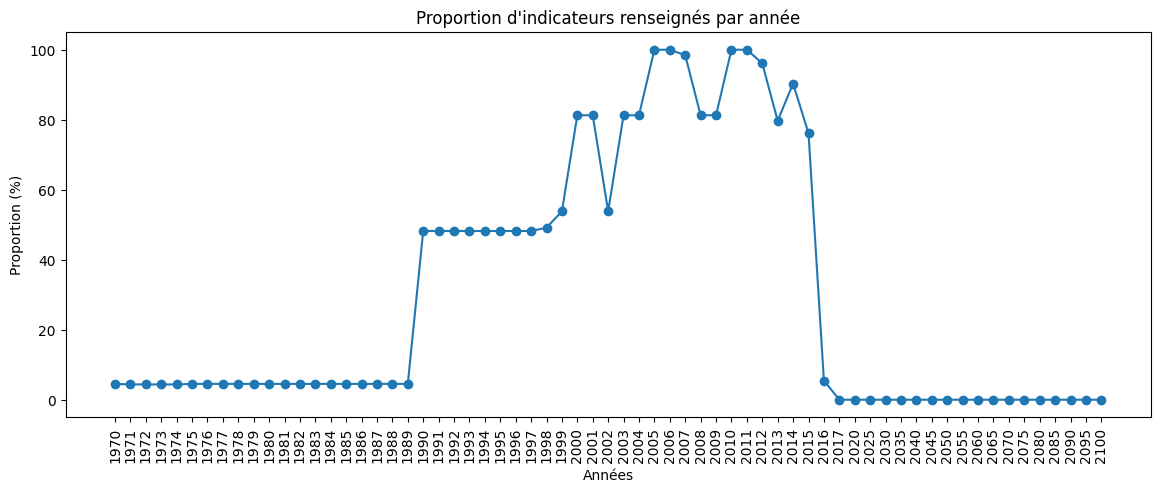

In [263]:
plt.figure(figsize=(14, 5))
plt.plot(
    proportion_indicateurs_par_annee.index,
    proportion_indicateurs_par_annee.values * 100,
    marker="o"
)
plt.xticks(rotation=90)
plt.title("Proportion d'indicateurs renseignés par année")
plt.xlabel("Années")
plt.ylabel("Proportion (%)")
plt.show()

#### Sélection des années à conserver

Les années futures sont très peu, voire pas du tout, renseignées.<br>
D’un point de vue métier, elles ne doivent pas être utilisées comme des observations historiques.

Nous retenons donc ici les années **2000 à 2015**, qui constituent un compromis cohérent entre :
- actualité relative des données ;
- niveau de complétude ;
- stabilité du périmètre pour la suite de l’analyse.

In [264]:
annees_utiles = [
    annee for annee in annees_cols
    if 2000 <= int(annee) <= 2015
]

print("Années utiles retenues :")
print(annees_utiles)

Années utiles retenues :
['2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015']


### 2.3 Réduction du périmètre via une approche data

Nous appliquons maintenant la même logique de filtrage à l’existant, <br>
mais cette fois-ci avec un angle **qualité de données**.<br>
L’objectif est de conserver les années et les indicateurs les plus riches en informations.

In [265]:
colonnes_hors_annees = [col for col in df_data_filtre.columns if not col.isnumeric()]
colonnes_finales = colonnes_hors_annees + annees_utiles

df_data_annees = df_data_filtre[colonnes_finales].copy()

print("Dimensions avant filtrage des années :", df_data_filtre.shape)
print("Dimensions après filtrage des années :", df_data_annees.shape)

Dimensions avant filtrage des années : (121149, 101)
Dimensions après filtrage des années : (121149, 52)


#### 2.3.1 Proportion d’années renseignées par indicateur

Pour chaque indicateur, nous calculons la proportion d’années utiles pour lesquelles au moins une valeur est disponible.

In [266]:
def calcul_proportion_presence(table_presence, axis):
    return table_presence.mean(axis=axis)

presence_indicateur_annees_utiles = (
    df_data_annees
    .groupby("Indicator Code")[annees_utiles]
    .apply(lambda groupe: groupe.notna().any(axis=0))
    .astype(int)
)

proportion_annees_par_indicateur = calcul_proportion_presence(
    presence_indicateur_annees_utiles,
    axis=1
).sort_values(ascending=False)

print("Statistiques sur la proportion d'années renseignées par indicateur :")
print((proportion_annees_par_indicateur * 100).describe().round(2))

Statistiques sur la proportion d'années renseignées par indicateur :
count    641.00
mean      86.39
std       21.69
min       31.25
25%       93.75
50%       93.75
75%      100.00
max      100.00
dtype: float64


#### 2.3.2 Nombre de pays renseignés par indicateur et par année

Pour identifier les indicateurs les plus riches en données, nous passons le jeu en format long puis comptons, pour chaque couple *(indicateur, année)*, le nombre de pays disposant d’une valeur.

In [267]:
df_long = df_data_annees.melt(
    id_vars=["Country Code", "Indicator Code", "Indicator Name"],
    value_vars=annees_utiles,
    var_name="Annee",
    value_name="Valeur"
)

df_pays_par_indicateur_annee = (
    df_long
    .groupby(["Indicator Code", "Indicator Name", "Annee"])["Valeur"]
    .apply(lambda serie: serie.notna().sum())
    .reset_index(name="nb_pays_renseignes")
    .sort_values(by="nb_pays_renseignes", ascending=False)
)
display(df_pays_par_indicateur_annee.head(10))

,Indicator Code,Indicator Name,Annee,nb_pays_renseignes
4011,IT.NET.USER.P2,Internet users (per 100 people),2011,180
4007,IT.NET.USER.P2,Internet users (per 100 people),2007,180
4008,IT.NET.USER.P2,Internet users (per 100 people),2008,179
4014,IT.NET.USER.P2,Internet users (per 100 people),2014,178
4013,IT.NET.USER.P2,Internet users (per 100 people),2013,178
4012,IT.NET.USER.P2,Internet users (per 100 people),2012,178
4010,IT.NET.USER.P2,Internet users (per 100 people),2010,178
4009,IT.NET.USER.P2,Internet users (per 100 people),2009,178
4015,IT.NET.USER.P2,Internet users (per 100 people),2015,178
4002,IT.NET.USER.P2,Internet users (per 100 people),2002,175


#### 2.3.3 Classement global des indicateurs les plus riches

Nous agrégeons ensuite le nombre de pays renseignés sur l’ensemble des années utiles afin d’obtenir un score global de richesse.<br>
Plus ce score est élevé, plus l’indicateur est exploitable pour la suite.

In [268]:
df_classement = (
    df_pays_par_indicateur_annee
    .groupby(["Indicator Code", "Indicator Name"], as_index=False)["nb_pays_renseignes"]
    .sum()
    .rename(columns={"nb_pays_renseignes": "score_global"})
    .sort_values("score_global", ascending=False)
)

display(df_classement.head(20))

,Indicator Code,Indicator Name,score_global
250,IT.NET.USER.P2,Internet users (per 100 people),2815
448,SP.SEC.UTOT.IN,Population of the official age for upper secon...,2747
447,SP.SEC.UTOT.FE.IN,Population of the official age for upper secon...,2747
449,SP.SEC.UTOT.MA.IN,Population of the official age for upper secon...,2747
441,SP.SEC.LTOT.FE.IN,Population of the official age for lower secon...,2745
442,SP.SEC.LTOT.IN,Population of the official age for lower secon...,2745
443,SP.SEC.LTOT.MA.IN,Population of the official age for lower secon...,2745
444,SP.SEC.TOTL.FE.IN,Population of the official age for secondary e...,2742
445,SP.SEC.TOTL.IN,Population of the official age for secondary e...,2742
446,SP.SEC.TOTL.MA.IN,Population of the official age for secondary e...,2742


#### 2.3.4 Jointure avec les métadonnées des indicateurs

Nous enrichissons le classement avec la catégorie métier afin de faciliter la sélection finale.

In [269]:
resultat = df_classement.merge(
    df_series_filtre[["Series Code", "Topic"]],
    left_on="Indicator Code",
    right_on="Series Code",
    how="left"
)[["Indicator Code", "Indicator Name", "Topic", "score_global"]]

print("Top 20 indicateurs classés par richesse de données :")
display(resultat.head(20))

Top 20 indicateurs classés par richesse de données :


,Indicator Code,Indicator Name,Topic,score_global
0,IT.NET.USER.P2,Internet users (per 100 people),Infrastructure: Communications,2815
1,SP.SEC.UTOT.IN,Population of the official age for upper secon...,Population,2747
2,SP.SEC.UTOT.FE.IN,Population of the official age for upper secon...,Population,2747
3,SP.SEC.UTOT.MA.IN,Population of the official age for upper secon...,Population,2747
4,SP.SEC.LTOT.FE.IN,Population of the official age for lower secon...,Population,2745
5,SP.SEC.LTOT.IN,Population of the official age for lower secon...,Population,2745
6,SP.SEC.LTOT.MA.IN,Population of the official age for lower secon...,Population,2745
7,SP.SEC.TOTL.FE.IN,Population of the official age for secondary e...,Population,2742
8,SP.SEC.TOTL.IN,Population of the official age for secondary e...,Population,2742
9,SP.SEC.TOTL.MA.IN,Population of the official age for secondary e...,Population,2742


#### 2.3.5 Sélection finale d’une quinzaine d’indicateurs maximum

Nous partons des indicateurs les plus riches en données, puis nous retenons ceux qui ont du sens pour la problématique métier.
La variable `indicateurs_retenus_data` contiendra la sélection finale utilisée dans la suite du projet.

> Remarque : la liste ci-dessous peut être ajustée après lecture du classement, mais elle doit rester limitée à une quinzaine d’indicateurs maximum.

In [270]:
selection_top = resultat.head(40).copy()

display(selection_top[["Indicator Code", "Indicator Name", "Topic", "score_global"]])

indicateurs_retenus_data = [
    "SP.POP.TOTL",          # Population, total
    "SP.POP.1524.TO.UN",    # Population ages 15-24, total
    "SP.POP.GROW",          # Population growth (annual %)
    "SE.XPD.TOTL.GD.ZS",    # Government expenditure on education, total (% of GDP)
    "SE.XPD.TOTL.GB.ZS",    # Government expenditure on education, total (% of government expenditure)
    "SE.PRM.NENR",          # Adjusted net enrollment rate, primary
    "SE.SEC.NENR",          # Adjusted net enrollment rate, secondary
    "SE.PRM.CMPT.ZS",       # Primary completion rate, total (% of relevant age group)
    "SE.ADT.LITR.ZS",       # Adult literacy rate, population 15+ years, both sexes (%)
    "SE.ENR.PRSC.FM.ZS",    # Gender parity index for gross enrollment ratio, pre-primary
    "SE.ENR.PRIM.FM.ZS",    # Gender parity index for gross enrollment ratio, primary
    "SE.ENR.SECO.FM.ZS",    # Gender parity index for gross enrollment ratio, secondary
    "NY.GNP.PCAP.CD",       # GNI per capita, Atlas method (current US$)
    "NY.GNP.ATLS.CD",       # GNI, Atlas method (current US$)
    "IT.NET.USER.P2"        # Internet users (per 100 people)
]

indicateurs_retenus_data = [
    code for code in indicateurs_retenus_data
    if code in resultat["Indicator Code"].values
]

df_final = df_data_annees[
    df_data_annees["Indicator Code"].isin(indicateurs_retenus_data)
].copy()

print("Nombre d'indicateurs retenus pour la suite :", len(indicateurs_retenus_data))
print("Indicateurs retenus :")
print(indicateurs_retenus_data)
print("Dimensions du jeu de données final :", df_final.shape)

,Indicator Code,Indicator Name,Topic,score_global
0,IT.NET.USER.P2,Internet users (per 100 people),Infrastructure: Communications,2815
1,SP.SEC.UTOT.IN,Population of the official age for upper secon...,Population,2747
2,SP.SEC.UTOT.FE.IN,Population of the official age for upper secon...,Population,2747
3,SP.SEC.UTOT.MA.IN,Population of the official age for upper secon...,Population,2747
4,SP.SEC.LTOT.FE.IN,Population of the official age for lower secon...,Population,2745
5,SP.SEC.LTOT.IN,Population of the official age for lower secon...,Population,2745
6,SP.SEC.LTOT.MA.IN,Population of the official age for lower secon...,Population,2745
7,SP.SEC.TOTL.FE.IN,Population of the official age for secondary e...,Population,2742
8,SP.SEC.TOTL.IN,Population of the official age for secondary e...,Population,2742
9,SP.SEC.TOTL.MA.IN,Population of the official age for secondary e...,Population,2742


Nombre d'indicateurs retenus pour la suite : 3
Indicateurs retenus :
['SP.POP.1524.TO.UN', 'NY.GNP.PCAP.CD', 'IT.NET.USER.P2']
Dimensions du jeu de données final : (567, 52)


#### 2.3.4 Représentation graphique de la disponibilité des données

Afin de représenter la disponibilité des données selon les pays et les années pour un indicateur donné, nous utilisons une carte de chaleur.

Cette visualisation permet de repérer rapidement les zones bien renseignées et les éventuelles lacunes.

In [271]:
def analyse_indicateur(
    df,
    indicateur_code,
    indicateur_nom,
    annees_utiles,
    type_plot="bar",
    top_n=15
):
    # === Filtrage ===
    df_viz = df[df["Indicator Code"] == indicateur_code].copy()
    annees_ok = [col for col in annees_utiles if col in df_viz.columns]

    # Dernière année
    derniere_annee = annees_ok[-1]

    # Top pays
    df_bar = df_viz[["Country Code", derniere_annee]].dropna().copy()
    df_bar = df_bar.sort_values(by=derniere_annee, ascending=False).head(top_n)

    top_pays = df_bar["Country Code"].tolist()

    #  BARPLOT

    if type_plot == "bar":
        plt.figure(figsize=(10, 6))
        plt.barh(df_bar["Country Code"], df_bar[derniere_annee])
        plt.gca().invert_yaxis()

        plt.title(f"Top {top_n} pays - {indicateur_nom} ({derniere_annee})")
        plt.xlabel("Valeur")
        plt.ylabel("Pays")
        plt.tight_layout()
        plt.show()

    #  LINEPLOT

    elif type_plot == "line":
        df_lignes = df_viz[df_viz["Country Code"].isin(top_pays)].copy()
        df_lignes = df_lignes.set_index("Country Name")[annees_ok].T

        plt.figure(figsize=(12, 6))

        for col in df_lignes.columns:
            plt.plot(df_lignes.index, df_lignes[col], marker="o", label=col)

        plt.title(f"Évolution - {indicateur_nom}")
        plt.xlabel("Années")
        plt.ylabel("Valeur")
        plt.xticks(rotation=45)
        plt.legend(bbox_to_anchor=(1.05, 1))
        plt.tight_layout()
        plt.show()

    # HEATMAP

    elif type_plot == "heatmap":
        df_heat = df_viz[df_viz["Country Code"].isin(top_pays)].copy()

        df_pivot = pd.pivot_table(
            df_heat,
            index="Country Name",
            values=annees_ok,
            aggfunc="first"
        )

        # Normalisation
        df_pivot_norm = df_pivot.sub(df_pivot.min(axis=1), axis=0).div(
            df_pivot.max(axis=1) - df_pivot.min(axis=1), axis=0
        )

        plt.figure(figsize=(12, 8))
        sns.heatmap(df_pivot_norm, cmap="YlGnBu", linewidths=0.2)

        plt.title(f"Évolution relative - {indicateur_nom}")
        plt.xlabel("Années")
        plt.ylabel("Pays")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

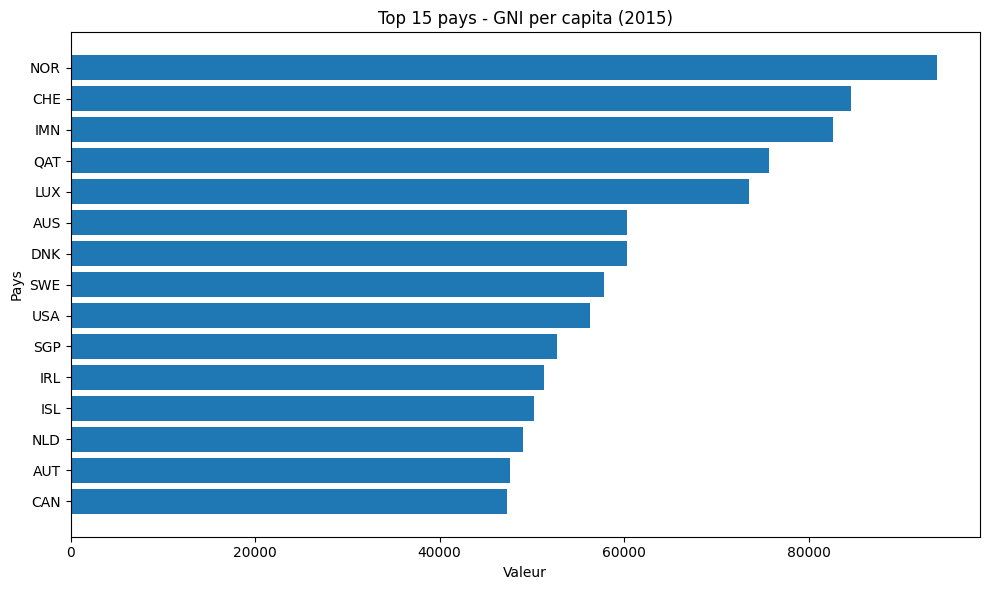

In [272]:
analyse_indicateur(
    df_final,
    indicateurs_retenus_data[1],
    "GNI per capita",
    annees_utiles,
    type_plot="bar"
)

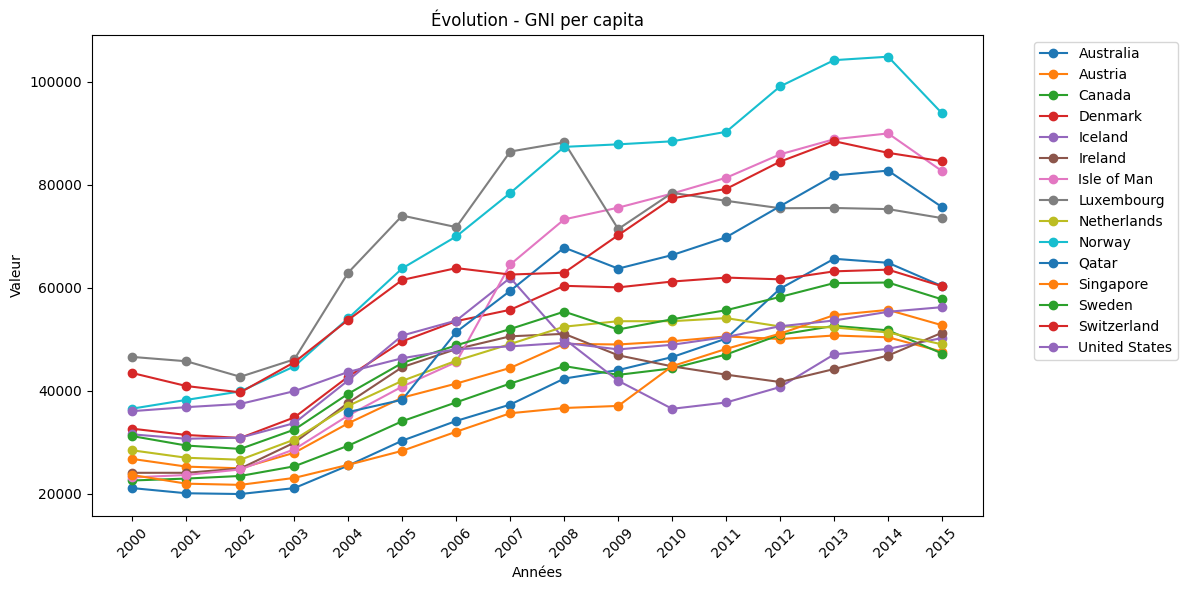

In [273]:
analyse_indicateur(
    df_final,
    indicateurs_retenus_data[1],
    "GNI per capita",
    annees_utiles,
    type_plot="line"
)

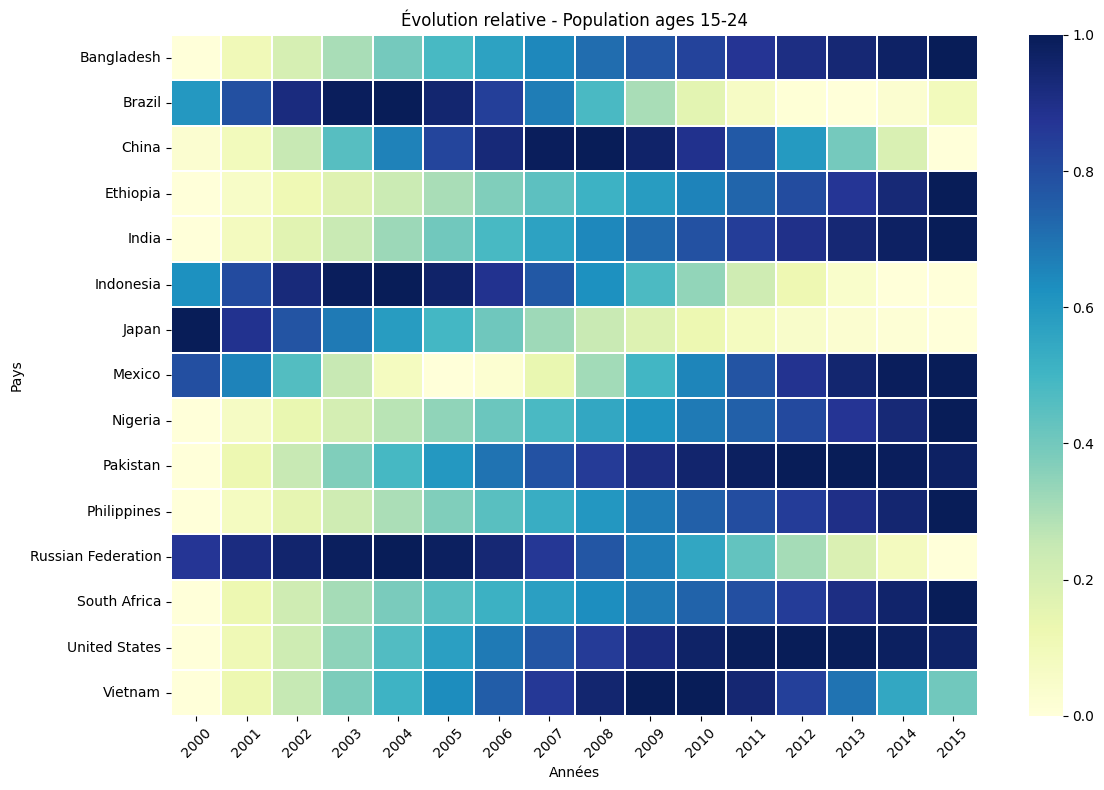

In [274]:
analyse_indicateur(
    df_final,
    indicateurs_retenus_data[0],
    "Population ages 15-24",
    annees_utiles,
    type_plot="heatmap"
)

### CONCLUSION EXERCICE_1_&_2

Cette étape a permis de réduire le périmètre du jeu de données de manière progressive et argumentée.

Les principaux choix méthodologiques ont été les suivants :
- conservation des seuls pays valides ;
- sélection de catégories d’indicateurs pertinentes au regard de la problématique métier ;
- restriction du périmètre temporel aux années utiles ;
- évaluation de la complétude des données pour identifier les indicateurs les plus exploitables.

Le jeu de données obtenu est désormais plus cohérent, plus lisible et mieux adapté à la poursuite de l’analyse.

## EXECRICE_03 Analyse des corrélations entre indicateurs

### Analyse des corrélations entre indicateurs

Après avoir nettoyé et réduit le jeu de données (parties 1 et 2), cette étape vise à identifier les indicateurs redondants d’un point de vue statistique.

Deux indicateurs fortement corrélés apportent une information similaire.  
Nous allons donc :

- construire un tableau pays × indicateurs ;
- calculer les matrices de corrélation (Pearson et Spearman) ;
- visualiser ces corrélations ;
- supprimer les indicateurs redondants.

Seuls les indicateurs faiblement corrélés seront conservés pour la suite de l’analyse.

###  3.1.1 Identification des indicateurs redondants


Afin d’enrichir l’analyse, nous avons reconstruit un jeu de données à partir de plusieurs indicateurs EdStats pertinents.

Nous avons ensuite calculé des matrices de corrélation de Pearson et de Spearman sur un tableau pays × indicateurs.

Les variables présentant une corrélation absolue supérieure à 0.7 ont été considérées comme redondantes et supprimées afin d’éviter le double comptage d’information.

In [275]:
indicateurs_retenus_data = [
    "SP.POP.TOTL",          # Population, total
    "SP.POP.1524.TO.UN",    # Population ages 15-24, total
    "SP.POP.GROW",          # Population growth (annual %)
    "SE.XPD.TOTL.GD.ZS",    # Government expenditure on education, total (% of GDP)
    "SE.XPD.TOTL.GB.ZS",    # Government expenditure on education, total (% of government expenditure)
    "SE.PRM.NENR",          # Adjusted net enrollment rate, primary
    "SE.SEC.NENR",          # Adjusted net enrollment rate, secondary
    "SE.PRM.CMPT.ZS",       # Primary completion rate, total (% of relevant age group)
    "SE.ADT.LITR.ZS",       # Adult literacy rate, population 15+ years, both sexes (%)
    "SE.ENR.PRSC.FM.ZS",    # Gender parity index for gross enrollment ratio, pre-primary
    "SE.ENR.PRIM.FM.ZS",    # Gender parity index for gross enrollment ratio, primary
    "SE.ENR.SECO.FM.ZS",    # Gender parity index for gross enrollment ratio, secondary
    "NY.GNP.PCAP.CD",       # GNI per capita, Atlas method (current US$)
    "NY.GNP.ATLS.CD",       # GNI, Atlas method (current US$)
    "IT.NET.USER.P2"        # Internet users (per 100 people)
]

codes_disponibles = set(df_data["Indicator Code"].unique())

codes_presents = [c for c in indicateurs_retenus_data if c in codes_disponibles]
codes_absents = [c for c in indicateurs_retenus_data if c not in codes_disponibles]


df_final_v2 = df_data[
    df_data["Indicator Code"].isin(indicateurs_retenus_data)
].copy()

df_final_v2.head(5)

,Country Name,Country Code,Indicator Name,Indicator Code,1970,1971,1972,1973,1974,1975,...,2060,2065,2070,2075,2080,2085,2090,2095,2100,Unnamed: 69
20,Arab World,ARB,"Adult literacy rate, population 15+ years, bot...",SE.ADT.LITR.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1224,Arab World,ARB,Expenditure on education as % of total governm...,SE.XPD.TOTL.GB.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1251,Arab World,ARB,"GNI per capita, Atlas method (current US$)",NY.GNP.PCAP.CD,327.231429,362.069612,432.012749,510.427899,746.961615,1020.806202,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1260,Arab World,ARB,Government expenditure on education as % of GD...,SE.XPD.TOTL.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1325,Arab World,ARB,"Gross enrolment ratio, primary and secondary, ...",SE.ENR.PRSC.FM.ZS,0.620240,0.618380,0.624470,0.631840,0.639070,0.643680,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [276]:
# adapte cette liste à tes années retenues dans le projet
annees_utiles = ["2000", "2005", "2010", "2015"]

df_corr_v2 = df_final_v2.copy()
df_corr_v2["valeur_moyenne"] = df_corr_v2[annees_utiles].mean(axis=1)

df_corr_v2[["Country Name", "Indicator Code", "valeur_moyenne"]].head()

,Country Name,Indicator Code,valeur_moyenne
20,Arab World,SE.ADT.LITR.ZS,73.578412
1224,Arab World,SE.XPD.TOTL.GB.ZS,NaN
1251,Arab World,NY.GNP.PCAP.CD,3933.190267
1260,Arab World,SE.XPD.TOTL.GD.ZS,NaN
1325,Arab World,SE.ENR.PRSC.FM.ZS,0.905180


In [277]:
df_pivot_corr_v2 = pd.pivot_table(
    df_corr_v2,
    index="Country Name",
    columns="Indicator Code",
    values="valeur_moyenne"
)

print(df_pivot_corr_v2.shape)
df_pivot_corr_v2.head()

(242, 14)


Indicator Code,IT.NET.USER.P2,NY.GNP.PCAP.CD,SE.ADT.LITR.ZS,SE.ENR.PRIM.FM.ZS,SE.ENR.PRSC.FM.ZS,SE.ENR.SECO.FM.ZS,SE.PRM.CMPT.ZS,SE.PRM.NENR,SE.SEC.NENR,SE.XPD.TOTL.GB.ZS,SE.XPD.TOTL.GD.ZS,SP.POP.1524.TO.UN,SP.POP.GROW,SP.POP.TOTL
Country Name,,,,,,,,,,,,,,
Afghanistan,4.494716,446.666667,NaN,0.490828,0.610060,0.462717,NaN,NaN,48.878929,14.78828,3.389515,5558200.50,3.280245,26926053.75
Albania,28.602730,3122.500000,NaN,0.979100,0.964695,0.958110,98.771970,93.461872,76.478279,10.74750,3.262550,572256.25,-0.484204,2973559.50
Algeria,14.258912,3387.500000,NaN,0.928962,0.984533,1.059200,93.623009,94.113062,NaN,NaN,NaN,7006239.50,1.618595,35115315.50
American Samoa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.048227,56953.25
Andorra,56.513650,NaN,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.639910,7955.00,0.850338,76680.00


In [278]:
df_pivot_corr_v2 = pd.pivot_table(
    df_corr_v2,
    index="Country Name",
    columns="Indicator Code",
    values="valeur_moyenne"
)

print(df_pivot_corr_v2.shape)
df_pivot_corr_v2.head()

(242, 14)


Indicator Code,IT.NET.USER.P2,NY.GNP.PCAP.CD,SE.ADT.LITR.ZS,SE.ENR.PRIM.FM.ZS,SE.ENR.PRSC.FM.ZS,SE.ENR.SECO.FM.ZS,SE.PRM.CMPT.ZS,SE.PRM.NENR,SE.SEC.NENR,SE.XPD.TOTL.GB.ZS,SE.XPD.TOTL.GD.ZS,SP.POP.1524.TO.UN,SP.POP.GROW,SP.POP.TOTL
Country Name,,,,,,,,,,,,,,
Afghanistan,4.494716,446.666667,NaN,0.490828,0.610060,0.462717,NaN,NaN,48.878929,14.78828,3.389515,5558200.50,3.280245,26926053.75
Albania,28.602730,3122.500000,NaN,0.979100,0.964695,0.958110,98.771970,93.461872,76.478279,10.74750,3.262550,572256.25,-0.484204,2973559.50
Algeria,14.258912,3387.500000,NaN,0.928962,0.984533,1.059200,93.623009,94.113062,NaN,NaN,NaN,7006239.50,1.618595,35115315.50
American Samoa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.048227,56953.25
Andorra,56.513650,NaN,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.639910,7955.00,0.850338,76680.00


In [279]:
df_pivot_corr_v2 = df_pivot_corr_v2.fillna(df_pivot_corr_v2.mean())

#### 3.1.2 Calcul des matrices de corrélation

Nous calculons les matrices de corrélation de Pearson et de Spearman entre les indicateurs.

In [280]:
corr_pearson_v2 = df_pivot_corr_v2.corr(method="pearson")
corr_spearman_v2 = df_pivot_corr_v2.corr(method="spearman")

##### Visualisation des corrélations

Une heatmap est utilisée pour visualiser les relations entre indicateurs.

Les zones rouges indiquent une corrélation positive forte, tandis que les zones bleues indiquent une corrélation négative forte.

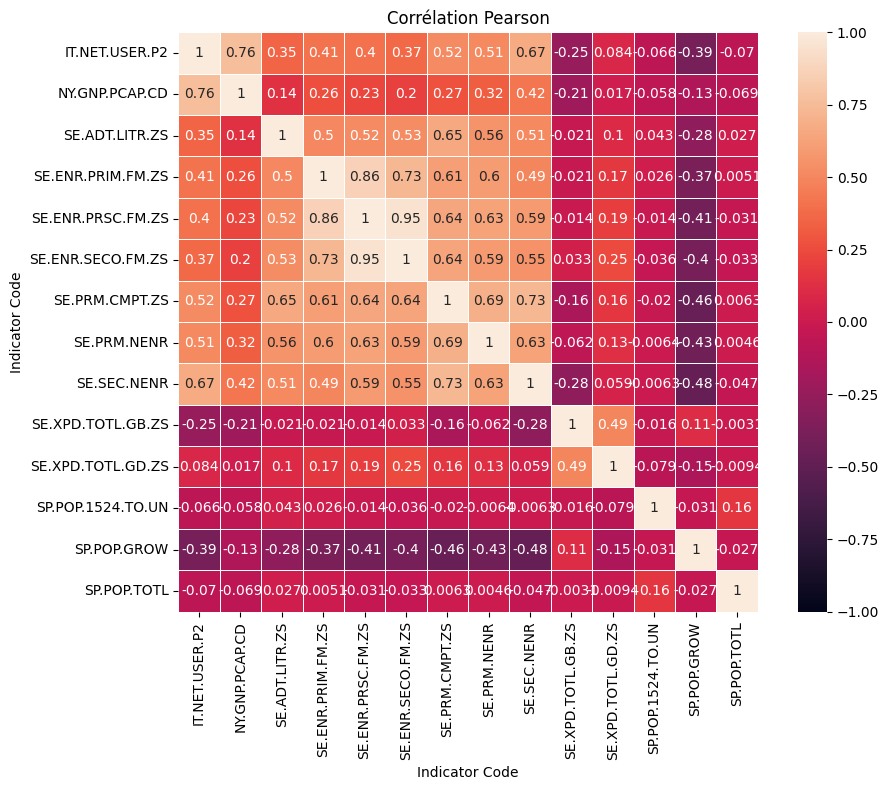

In [281]:
#Pearson
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_pearson_v2,
    annot=True,
    fmt=".2g",
    cmap="rocket",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar=True
)

plt.title("Corrélation Pearson")
plt.xlabel("Indicator Code")
plt.ylabel("Indicator Code")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

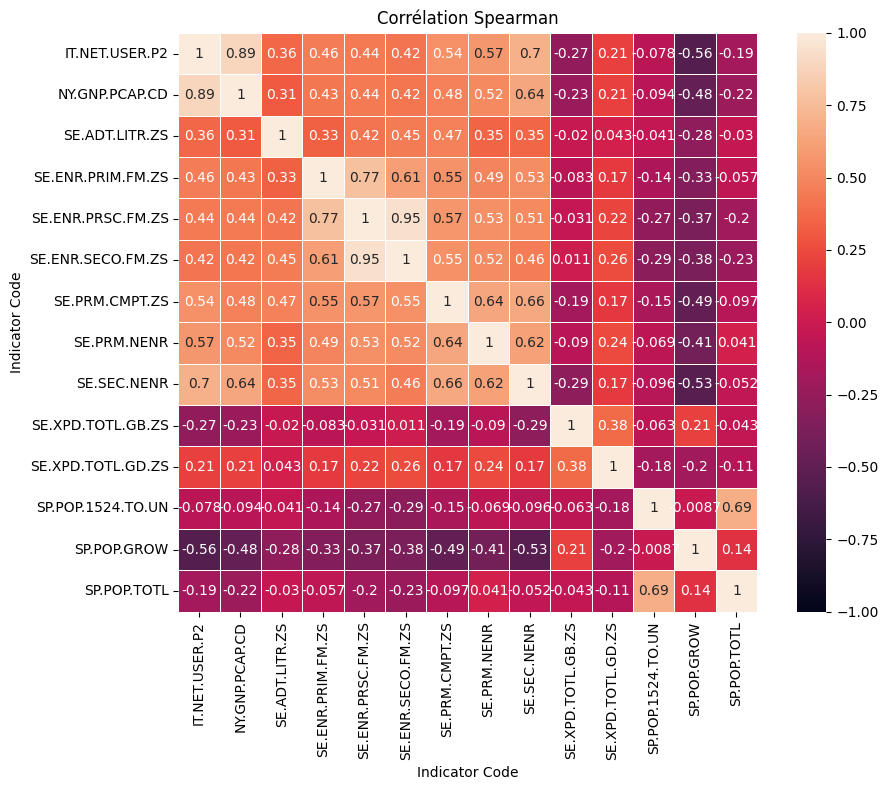

In [282]:
# Spearman
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_spearman_v2,
    annot=True,
    fmt=".2g",
    cmap="rocket",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar=True
)

plt.title("Corrélation Spearman")
plt.xlabel("Indicator Code")
plt.ylabel("Indicator Code")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [283]:
seuil_corr = 0.7

corr_abs = corr_pearson_v2.abs()

upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col] > seuil_corr)]

df_pivot_reduit_v2 = df_pivot_corr_v2.drop(columns=to_drop)

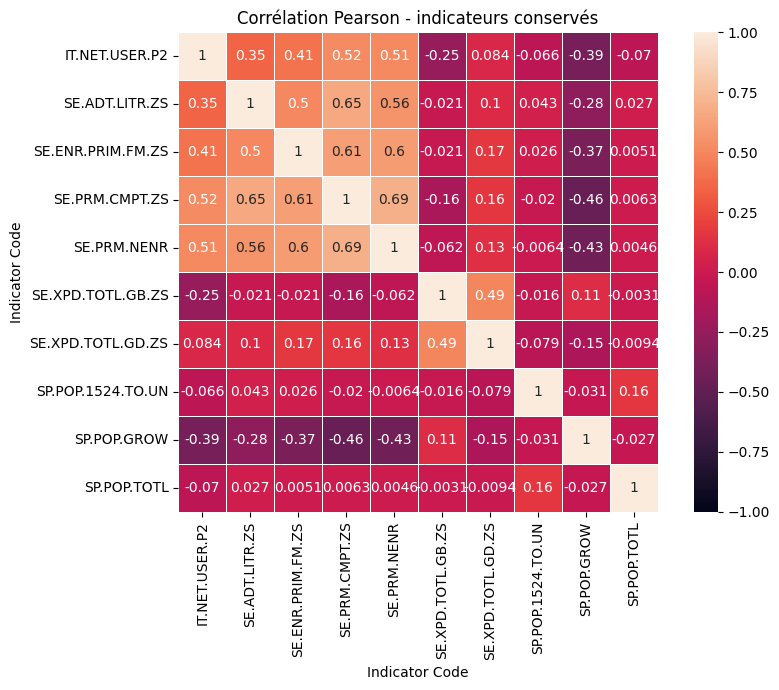

In [284]:
corr_final_v2 = df_pivot_reduit_v2.corr(method="pearson")

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_final_v2,
    annot=True,
    fmt=".2g",
    cmap="rocket",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)
plt.title("Corrélation Pearson - indicateurs conservés")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Cette analyse de corrélation a été réalisée sur un jeu de données déjà nettoyé et réduit.

Elle permet d’identifier les indicateurs redondants, c’est-à-dire ceux qui apportent une information similaire.

Les indicateurs présentant une corrélation élevée (|corrélation| > 0.7) ont été supprimés afin de simplifier le jeu de données tout en conservant l’essentiel de l’information.

Cette étape permet d’éviter les biais liés à la redondance et d’améliorer la lisibilité de l’analyse.

###  3.2 Analyse des Indicateurs restants plus pays perntinents pour l'implantation d'academy 

#### 3.2.1 Analyse univariée et sélection des pays


Après suppression des indicateurs redondants, nous avons analysé la distribution de chaque variable à l’aide de statistiques descriptives et de visualisations.

Nous avons ensuite construit un score pondéré afin de classer les pays selon leur potentiel d’implantation pour une academy.

Cette méthode est modulable : les poids peuvent être ajustés pour refléter différentes priorités stratégiques.


===== IT.NET.USER.P2 =====


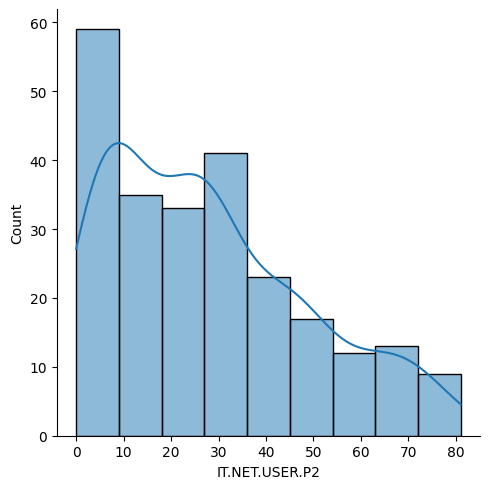

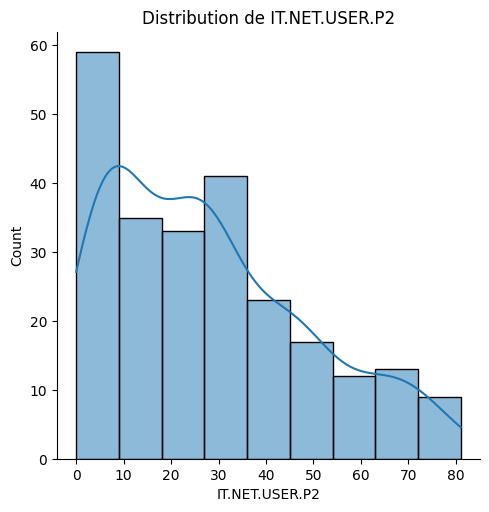


===== SE.ADT.LITR.ZS =====


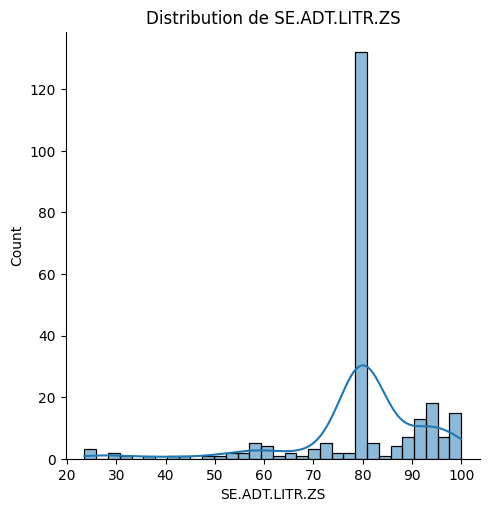


===== SE.ENR.PRIM.FM.ZS =====


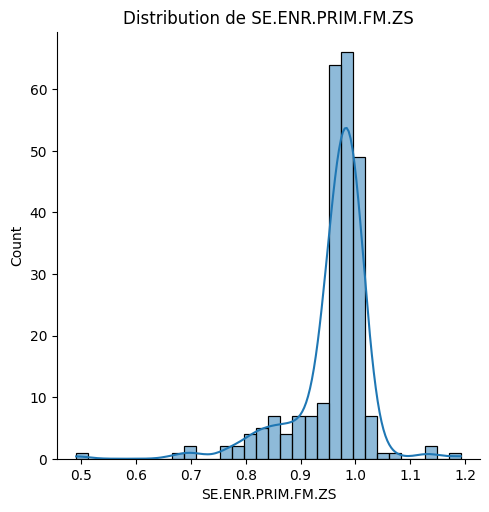


===== SE.PRM.CMPT.ZS =====


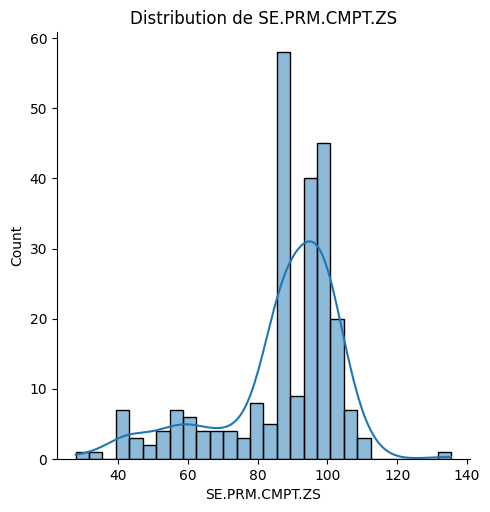


===== SE.PRM.NENR =====


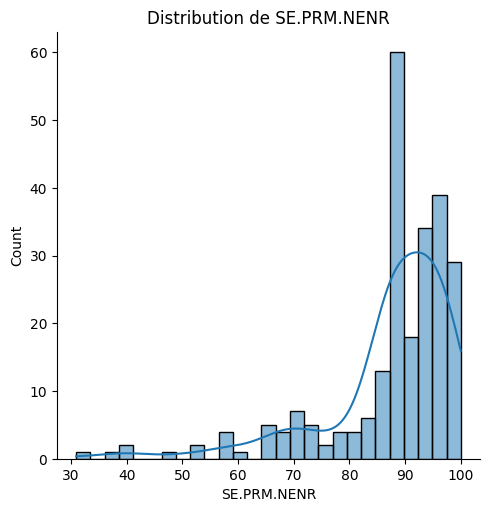


===== SE.XPD.TOTL.GB.ZS =====


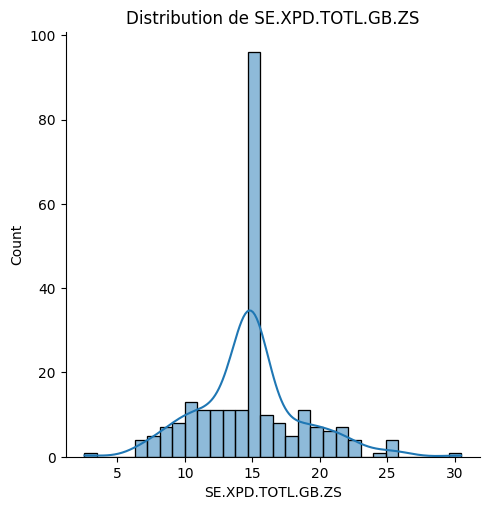


===== SE.XPD.TOTL.GD.ZS =====


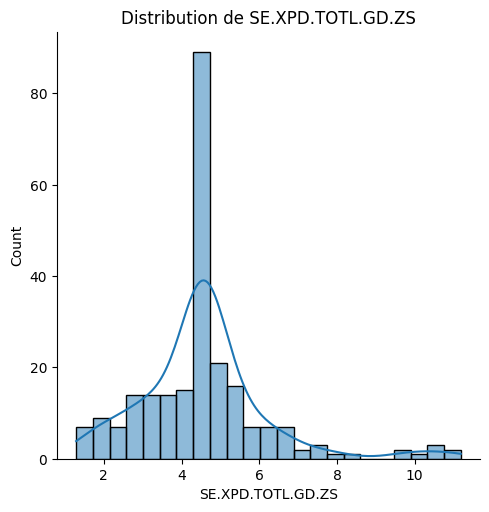


===== SP.POP.1524.TO.UN =====


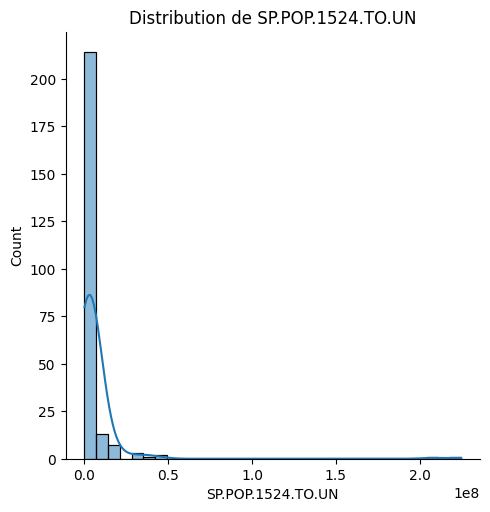


===== SP.POP.GROW =====


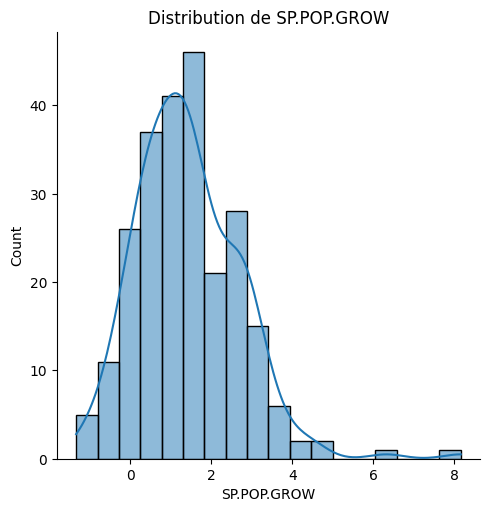


===== SP.POP.TOTL =====


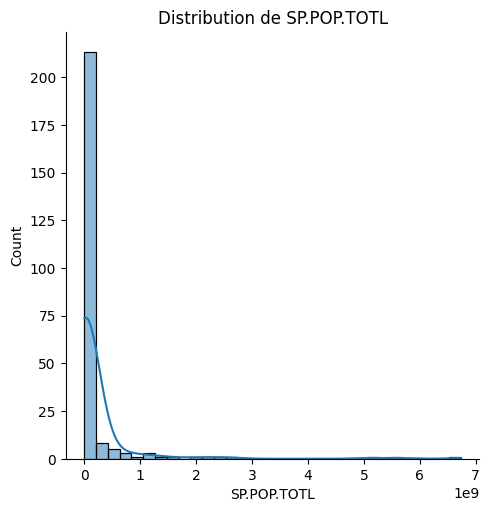

In [285]:
col = df_pivot_reduit_v2.columns[0]

sns.displot(df_pivot_reduit_v2[col], kde=True)
def analyse_indicateur(df, col):
    print(f"\n===== {col} =====")

    sns.displot(df[col], kde=True)
    plt.title(f"Distribution de {col}")
    plt.show()

for col in df_pivot_reduit_v2.columns:
    analyse_indicateur(df_pivot_reduit_v2, col)

#### 3.2.2 Analyse d’un indicateur

Nous analysons un indicateur afin de comprendre sa distribution et son pouvoir discriminant entre les pays.

Les statistiques descriptives permettent de résumer :
- la tendance centrale (moyenne, médiane)
- la dispersion (écart-type)
- la distribution (quantiles)

count    2.420000e+02
mean     6.096084e+06
std      2.027960e+07
min      2.728000e+03
25%      5.484907e+05
50%      2.374102e+06
75%      6.096084e+06
max      2.248224e+08
Name: SP.POP.1524.TO.UN, dtype: float64


<Figure size 800x500 with 0 Axes>

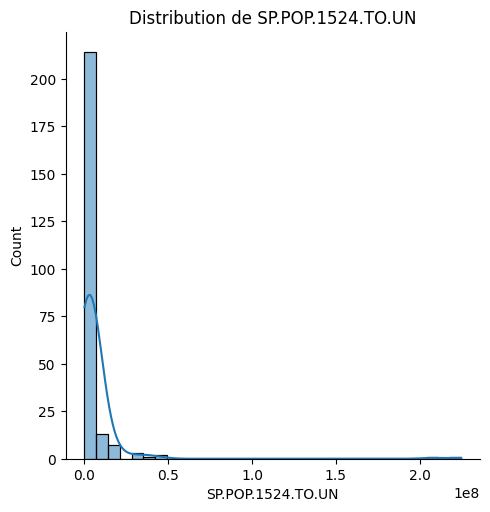

In [286]:
# Choix d’un indicateur (exemple)
col = df_pivot_reduit_v2.columns[7]

# Statistiques descriptives
print(df_pivot_reduit_v2[col].describe())

# Distribution
plt.figure(figsize=(8,5))
sns.displot(df_pivot_reduit_v2[col], kde=True)

plt.title(f"Distribution de {col}")
plt.show()

##### Interprétation des distributions

L’analyse des distributions montre que :

- Les indicateurs avec une forte dispersion (écart entre min et max élevé) permettent de mieux différencier les pays.
- Les indicateurs très concentrés autour de la moyenne sont moins discriminants.
- Une distribution asymétrique indique la présence de pays extrêmes (très performants ou très en retard).
- Les quantiles (25%, 50%, 75%) permettent de situer les pays dans la distribution.

Ces éléments sont essentiels pour identifier les indicateurs les plus pertinents dans la sélection des pays.

#### 3.2.3 Analyse de tous les indicateurs

Nous généralisons cette analyse à l’ensemble des indicateurs à l’aide d’une fonction.

In [287]:
poids = {
    "SP.POP.1524.TO.UN": 0.20,
    "SP.POP.GROW": 0.10,
    "SE.SEC.NENR": 0.20,
    "SE.ADT.LITR.ZS": 0.10,
    "NY.GNP.PCAP.CD": 0.25,
    "IT.NET.USER.P2": 0.15
}

variables_modele = [col for col in poids if col in df_pivot_reduit_v2.columns]
df_modele_v2 = df_pivot_reduit_v2[variables_modele].copy()

In [288]:
def calculer_score_pays(df, poids):
    scaler = MinMaxScaler()

    df_norm = pd.DataFrame(
        scaler.fit_transform(df),
        columns=df.columns,
        index=df.index
    )

    df_norm["score_global"] = 0

    for col in df.columns:
        df_norm["score_global"] += df_norm[col] * poids.get(col, 0)

    return df_norm.sort_values("score_global", ascending=False)
classement_pays = calculer_score_pays(df_modele_v2, poids)
classement_pays.head(10)

Indicator Code,SP.POP.1524.TO.UN,SP.POP.GROW,SE.ADT.LITR.ZS,IT.NET.USER.P2,score_global
Country Name,,,,,
China,0.924207,0.203553,0.908725,0.292727,0.339978
India,1.000000,0.296296,0.737512,0.112328,0.320230
Qatar,0.000481,1.000000,0.951387,0.590647,0.283832
United Arab Emirates,0.002911,0.806652,0.869632,0.685169,0.270986
United States,0.191561,0.236006,0.737512,0.793643,0.254711
Norway,0.002642,0.235223,0.737512,1.000000,0.247802
Iceland,0.000183,0.242570,0.737512,0.996515,0.247522
Singapore,0.002642,0.326517,0.935607,0.761938,0.241032
Sweden,0.004997,0.206272,0.737512,0.959707,0.239334


In [289]:
poids_manager = {
    "SP.POP.1524.TO.UN": 0.15,
    "SP.POP.GROW": 0.10,
    "SE.SEC.NENR": 0.25,
    "SE.ADT.LITR.ZS": 0.10,
    "NY.GNP.PCAP.CD": 0.20,
    "IT.NET.USER.P2": 0.20
}

calculer_score_pays(df_modele_v2, poids_manager).head(10)

Indicator Code,SP.POP.1524.TO.UN,SP.POP.GROW,SE.ADT.LITR.ZS,IT.NET.USER.P2,score_global
Country Name,,,,,
Qatar,0.000481,1.000000,0.951387,0.590647,0.313340
China,0.924207,0.203553,0.908725,0.292727,0.308404
United Arab Emirates,0.002911,0.806652,0.869632,0.685169,0.305099
Norway,0.002642,0.235223,0.737512,1.000000,0.297670
Iceland,0.000183,0.242570,0.737512,0.996515,0.297339
Sweden,0.004997,0.206272,0.737512,0.959707,0.287070
United States,0.191561,0.236006,0.737512,0.793643,0.284815
Netherlands,0.008703,0.191382,0.737512,0.948296,0.283854
Denmark,0.002866,0.187587,0.737512,0.946860,0.282312


#### 3.2.4 Méthode quantitative de sélection des pays

Nous construisons un score global basé sur les indicateurs retenus.

Chaque pays est évalué en fonction de la moyenne de ses performances sur l’ensemble des indicateurs.

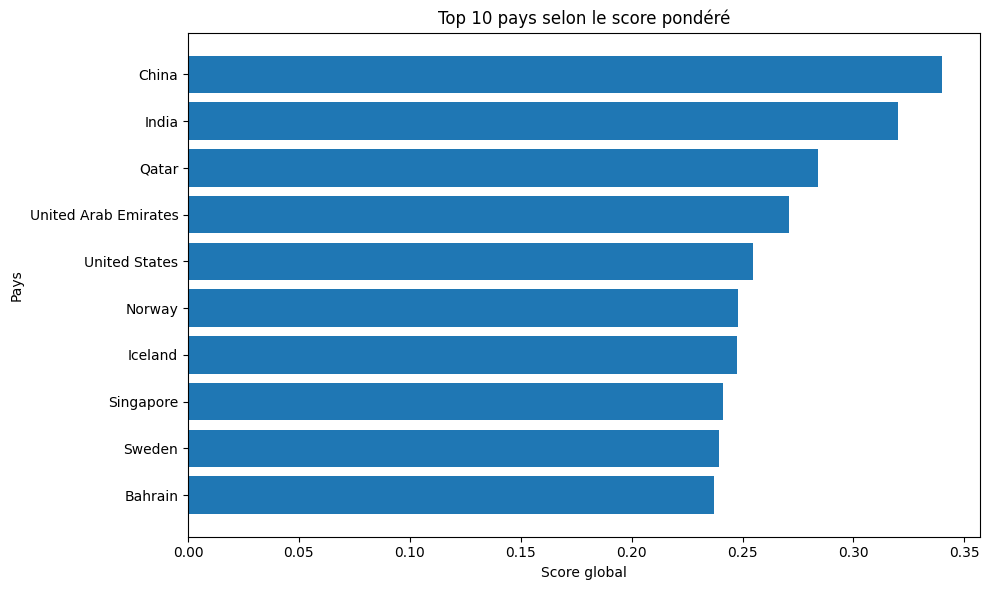

In [ ]:
# On récupère le top 10
top10 = classement_pays.head(10)

# Si tu veux afficher uniquement le score global
top10_scores = top10[["score_global"]]

# Graphique
plt.figure(figsize=(10, 6))

plt.barh(top10_scores.index, top10_scores["score_global"])

plt.gca().invert_yaxis()  # pour avoir le meilleur en haut

plt.title("Top 10 pays selon le score pondéré")
plt.xlabel("Score global")
plt.ylabel("Pays")

plt.tight_layout()
plt.show()

Ce graphique présente les 10 pays ayant le score global le plus élevé selon notre modèle pondéré.

On observe que ces pays combinent :
- une forte population jeune,
- un bon niveau éducatif,
- une capacité économique suffisante,
- et un accès au numérique.

Ils représentent donc les meilleures opportunités pour l’implantation d’une academy.

### Annexe — Définition des indicateurs

Les indicateurs utilisés dans cette analyse proviennent de la base de données EdStats de la Banque mondiale.

Ils ont été sélectionnés pour leur pertinence dans l’évaluation du potentiel d’implantation d’une academy.

| Code indicateur | Nom en anglais | Définition en français | Interprétation |
|----------------|--------------|----------------------|----------------|
| SP.POP.TOTL | Population, total | Population totale du pays | Taille globale du marché |
| SP.POP.1524.TO.UN | Population ages 15-24, total | Population âgée de 15 à 24 ans | Taille du public cible (jeunes) |
| SP.POP.GROW | Population growth (annual %) | Taux de croissance annuel de la population | Dynamique démographique |
| SE.XPD.TOTL.GD.ZS | Government expenditure on education (% GDP) | Dépenses publiques d’éducation (% du PIB) | Priorité donnée à l’éducation |
| SE.XPD.TOTL.GB.ZS | Government expenditure on education (% government expenditure) | Part du budget public consacrée à l’éducation | Engagement de l’État |
| SE.PRM.NENR | Adjusted net enrollment rate, primary | Taux net de scolarisation primaire | Accès à l’éducation de base |
| SE.SEC.NENR | Adjusted net enrollment rate, secondary | Taux net de scolarisation secondaire | Niveau d’éducation intermédiaire |
| SE.PRM.CMPT.ZS | Primary completion rate (%) | Taux d’achèvement du primaire | Qualité du système éducatif |
| SE.ADT.LITR.ZS | Adult literacy rate (%) | Taux d’alphabétisation des adultes | Niveau éducatif global |
| SE.ENR.PRSC.FM.ZS | Gender parity index (pre-primary) | Indice de parité filles/garçons (préscolaire) | Égalité d’accès à l’éducation |
| SE.ENR.PRIM.FM.ZS | Gender parity index (primary) | Indice de parité filles/garçons (primaire) | Inclusion éducative |
| SE.ENR.SECO.FM.ZS | Gender parity index (secondary) | Indice de parité filles/garçons (secondaire) | Équité dans l’éducation |
| NY.GNP.PCAP.CD | GNI per capita (US$) | Revenu national brut par habitant | Pouvoir d’achat |
| IT.NET.USER.P2 | Internet users (% population) | Utilisateurs d’Internet (% de la population) | Accès aux infrastructures numériques |